5장 성능 향상

In [ ]:
# 예제 5.1 파라미터 수

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense

inputs = Input(shape=(4096, ))   # 입력층 뉴런 4,096개
x = Dense(4096, activation='relu')(inputs)   # 은닉층 뉴런 4,096개
outpus = Dense(1000, activation='sigmoid')(x)   # 출력층 뉴런 1,000개

model = Model(inputs, outpus)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1000)                │       4,097,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,878,312 (79.64 MB)

 Trainable params: 20,878,312 (79.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 예제 5.2 성능 평가(이진 분류)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


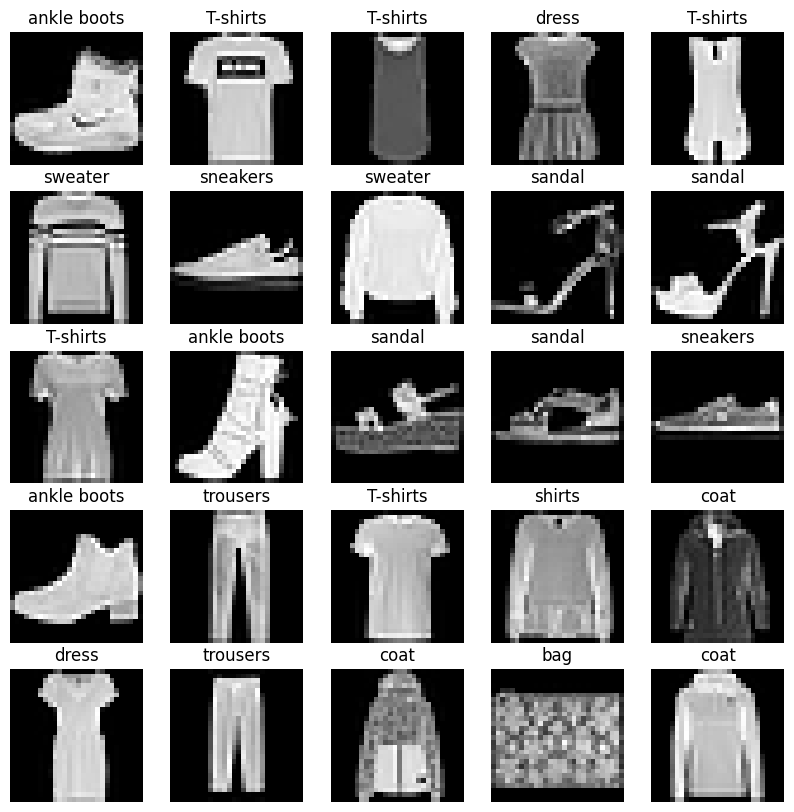

In [ ]:
# 학습 데이터 시각화(클래스명 표시)
class_names = ['T-shirts', 'trousers', 'sweater', 'dress', 'coat',
               'sandal', 'shirts', 'sneakers', 'bag', 'ankle boots']

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i].item()])   # 레이블(클래스명) 표시
    plt.axis('off')

plt.show()

In [ ]:
# 레이블 5(sandal)/7(sneakers) 샘플 추출
index = (y_train == 5) | (y_train == 7)
x_train = x_train[index]
y_train = (y_train[index] == 5).astype(int)   # 레이블 1(5)/0(7) 재지정

index = (y_test == 5) | (y_test == 7)
x_test = x_test[index]
y_test = (y_test[index] == 5).astype(int)

In [ ]:
# 데이터 정규화
x_train, x_test = x_train / 255., x_test / 255.

In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
x = Dense(16, activation='relu')(x)   # 은닉층 뉴런 16개
outputs = Dense(1, activation='sigmoid')(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer='Adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, batch_size=32, epochs=5, verbose=0,
          validation_split=0.2)   # 분할 비율 0.2

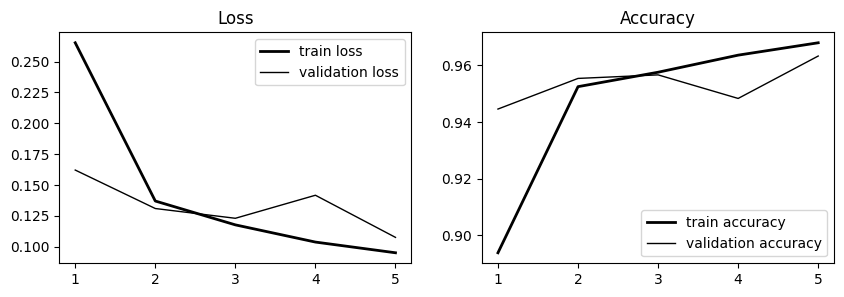

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

axs[0].plot(range(1, len(history.history['loss']) + 1),
            history.history['loss'], label='train loss',
            color='black', linewidth=2)
axs[0].plot(range(1, len(history.history['val_loss']) + 1),
            history.history['val_loss'], label='validation loss',
            color='black', linewidth=1)
axs[0].set_title('Loss')
axs[0].legend(loc='best')

axs[1].plot(range(1, len(history.history['accuracy']) + 1),
            history.history['accuracy'], label='train accuracy',
            color='black', linewidth=2)
axs[1].plot(range(1, len(history.history['val_accuracy']) + 1),
            history.history['val_accuracy'], label='validation accuracy',
            color='black', linewidth=1)
axs[1].set_title('Accuracy')
axs[1].legend(loc='best')

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
y_test: [1 0 1 0 1]
y_pred: [1 0 1 0 1]


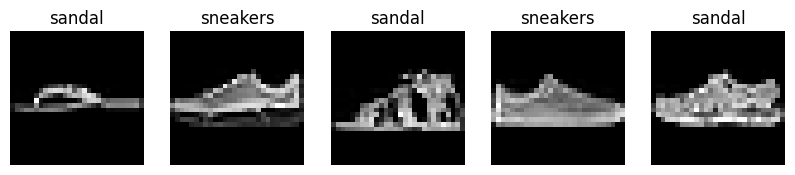

In [ ]:
# 모델 예측(임계치에 따라 0/1 판단)
class_names = ['sneakers', 'sandal']   # 클래스명

threshold = 0.5   # 임계치 0.5
y_pred = (model.predict(x_test) >= threshold).astype(int)

print(f"y_test: {y_test[:5]}")               # 테스트 데이터 레이블 확인
print(f"y_pred: {y_pred[:5].reshape(-1)}")   # 예측한 레이블 확인

# 예측 결과 시각화
plt.figure(figsize=(10, 10))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(class_names[y_pred[i].item()])   # 예측한 클래스명 표시
    plt.axis('off')

plt.show()

In [ ]:
#성능 평가 지표 출력
print(f"confusion matrix \n {confusion_matrix(y_test, y_pred)}")
print(f"accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"precision: {precision_score(y_test, y_pred):.2f}")

confusion matrix 
 [[975  25]
 [ 47 953]]
accuracy: 0.96
precision: 0.97
